# Introducción

En la presente demo usaremos el algoritmo de K-means para agrupar clientes en dos clústeres. La idea es usar el conjunto de datos que limpiamos y analizamos en el notebook anterior (ver notebook CreditRiskAnalysis.ipynb en el presente repositorio). Lo que queremos hacer es quitar la variable Risk que indica si un cliente tiene alto o bajo riesgo de no pagar un crédito y ver si el algoritmo de K-means logra segmentar a los clientes en dos clústeres uno de alto riesgo y otro de bajo riesgo.

Dado que K-means es un algoritmo no supervisado este segmentará a los clientes dependiendo de las características naturales de la información, es decir, el algoritmo no necesariamente va a discriminar entre clientes "Good" y clientes "Bad", sin embargo, al final de esta demo aplicaremos un "truco" para hacer que el algoritmo no supervisado intente segmentar a los clientes por la variable "Risk" sin que el algoritmo llegue a conocerla.

Antes de comenzar importemos las librerías necesarias:

In [2]:
# Importación de las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap
import warnings

#Módulos de Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve
)

# K-means
Como ya comentamos, los datos se encuentran limpios y listos para su uso ya que en el notebook CreditRiskAnalysis.ipynb hicimos toda la preparación y limpieza de estos. Entonces podemos pasar directamente a la ingesta de los datos hacia el modelo y al entrenamiento:

In [3]:
# Importación de los datos
df = pd.read_csv("dataset/german_data.csv")

# Selección de features
X = df.drop(columns=["Risk","Personal status and sex"])

# Identificación de features numéricas
features_numericas = X.select_dtypes(include=["int64"]).columns

# Identificación de features categóricas
features_categoricas = X.select_dtypes(include=["str"]).columns

# Definimos una transformación para el preprocesamiento
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas)
    ]
)

# Definimos el modelo en un pipeline
model = Pipeline(
    steps=[("preprocesamiento", preprocesamiento),
        ("clustering", KMeans(n_clusters=2, random_state=42, n_init="auto"))
    ]
)

# Entrenamiento del modelo
model.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Status of existing checking account','Duration in month', 'Credit history',...,'Foreign worker','Sex','Personal status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` 

Ahora que nuestro modelo ha sido entrenado podemos usarlo para predecir en que clúster está cada cliente. Hacerlo es inmediato con el siguiente comando:

In [4]:
df["Cluster"] = model.predict(X)
df[["Credit history","Cluster"]].head()

,Credit history,Cluster
0,critical account/other credits existing (not a...,1
1,existing credits paid back duly till now,0
2,critical account/other credits existing (not a...,1
3,existing credits paid back duly till now,1
4,delay in paying off in the past,1


La pregunta del millón, el valor de "Cluster" coincidirá con el valor de la variable "Risk". Podemos averiguarlo agrupando por Cluster y contanto cuantas veces aparece "Good" o "Bad" en cada segmento:

In [5]:
df.groupby(["Cluster","Risk"])["Risk"].count()

Cluster  Risk
0        Bad     109
         Good    201
1        Bad     191
         Good    499
Name: Risk, dtype: int64

Como podemos notar el algoritmo de K-means está segmentando a los clientes, en el clúster 0 hay 109 clientes "Bad" y 201 clientes "Good" y en clúster 1 hasta 191 clientes "Bad" y 499 "Good". Si suponemos que el clúster 0 representa a los clientes "Bad" y el clúster 1 a los clientes "Good" entonces podemos obtener la siguiente matriz de confusión:

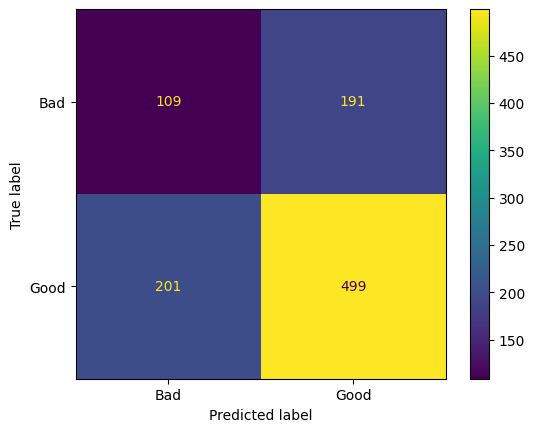

In [6]:
df["Risk_predicted"] = df["Cluster"].map({0:"Bad", 1:"Good"})
ConfusionMatrixDisplay.from_predictions(df["Risk"], df["Risk_predicted"])
plt.show()

Y las métricas son las siguientes:

In [7]:
print("Accuracy :", accuracy_score(df["Risk"], df["Risk_predicted"]))
print("Precision:", precision_score(df["Risk"], df["Risk_predicted"], pos_label="Bad" ))
print("Recall   :", recall_score(df["Risk"], df["Risk_predicted"], pos_label="Bad"))
print("F1       :", f1_score(df["Risk"], df["Risk_predicted"], pos_label="Bad"))

Accuracy : 0.608
Precision: 0.35161290322580646
Recall   : 0.36333333333333334
F1       : 0.35737704918032787


El mejor modelo de regresión logística que entrenamos en un notebook previo dio los siguientes resultados:

Como podemos notar, nuestro algoritmo no supervisado está muy lejos de ser comparable con una regresión logística. Esto era de esperarse, ya que K-means no conoce en ningún momento la variable "Risk" y solo intenta segmentar a los clientes en base a las "distancias" que existen entre los datos. Entonces no es recomendable suponer que 0 y 1 represente a las categorías "Bad" y "Good" o viceversa. En la siguiente sección haremos un análisis gráfico para intentar ver que es lo que realmente representa cada clúster.

# Interpretación de los clústeres para K=2
Para intentar  dilucidar que realmente representa el clúter 0 y el clúster 1 podemos hacer un análisis más profundo, por ejemplo, agrupar las variables numéricas por clúster y ver cómo cambia el promedio en cada clúster:

In [8]:
resultado = df.groupby("Cluster")[features_numericas].mean().transpose()
resultado["Diferencia relativa absoluta (%)"] = abs(resultado[0]-resultado[1])/resultado[0]*100
resultado

Cluster,0,1,Diferencia relativa absoluta (%)
Duration in month,19.438710,21.560870,10.917185
Credit amount,2877.774194,3448.040580,19.816231
Installment rate in percentage of disposable income,2.829032,3.037681,7.375275
Present residence since,2.867742,2.834783,1.149313
Age in years,32.803226,36.778261,12.117818
Number of existing credits at this bank,1.325806,1.443478,8.875489
Number of people being liable to provide maintenance for,1.045161,1.204348,15.230811


Como podemos notar, no parece haber mucha diferencia relativa porcentual (en valor absoluto) entre los promedios del clúster 0 vs los promedios del clúster 1. La mayor diferencia se observa en "Credit amount" con casi el 20%. Para seguir indagando que representa cada clúster veamos cómo se comparan las variables categóricas entre clústeres:

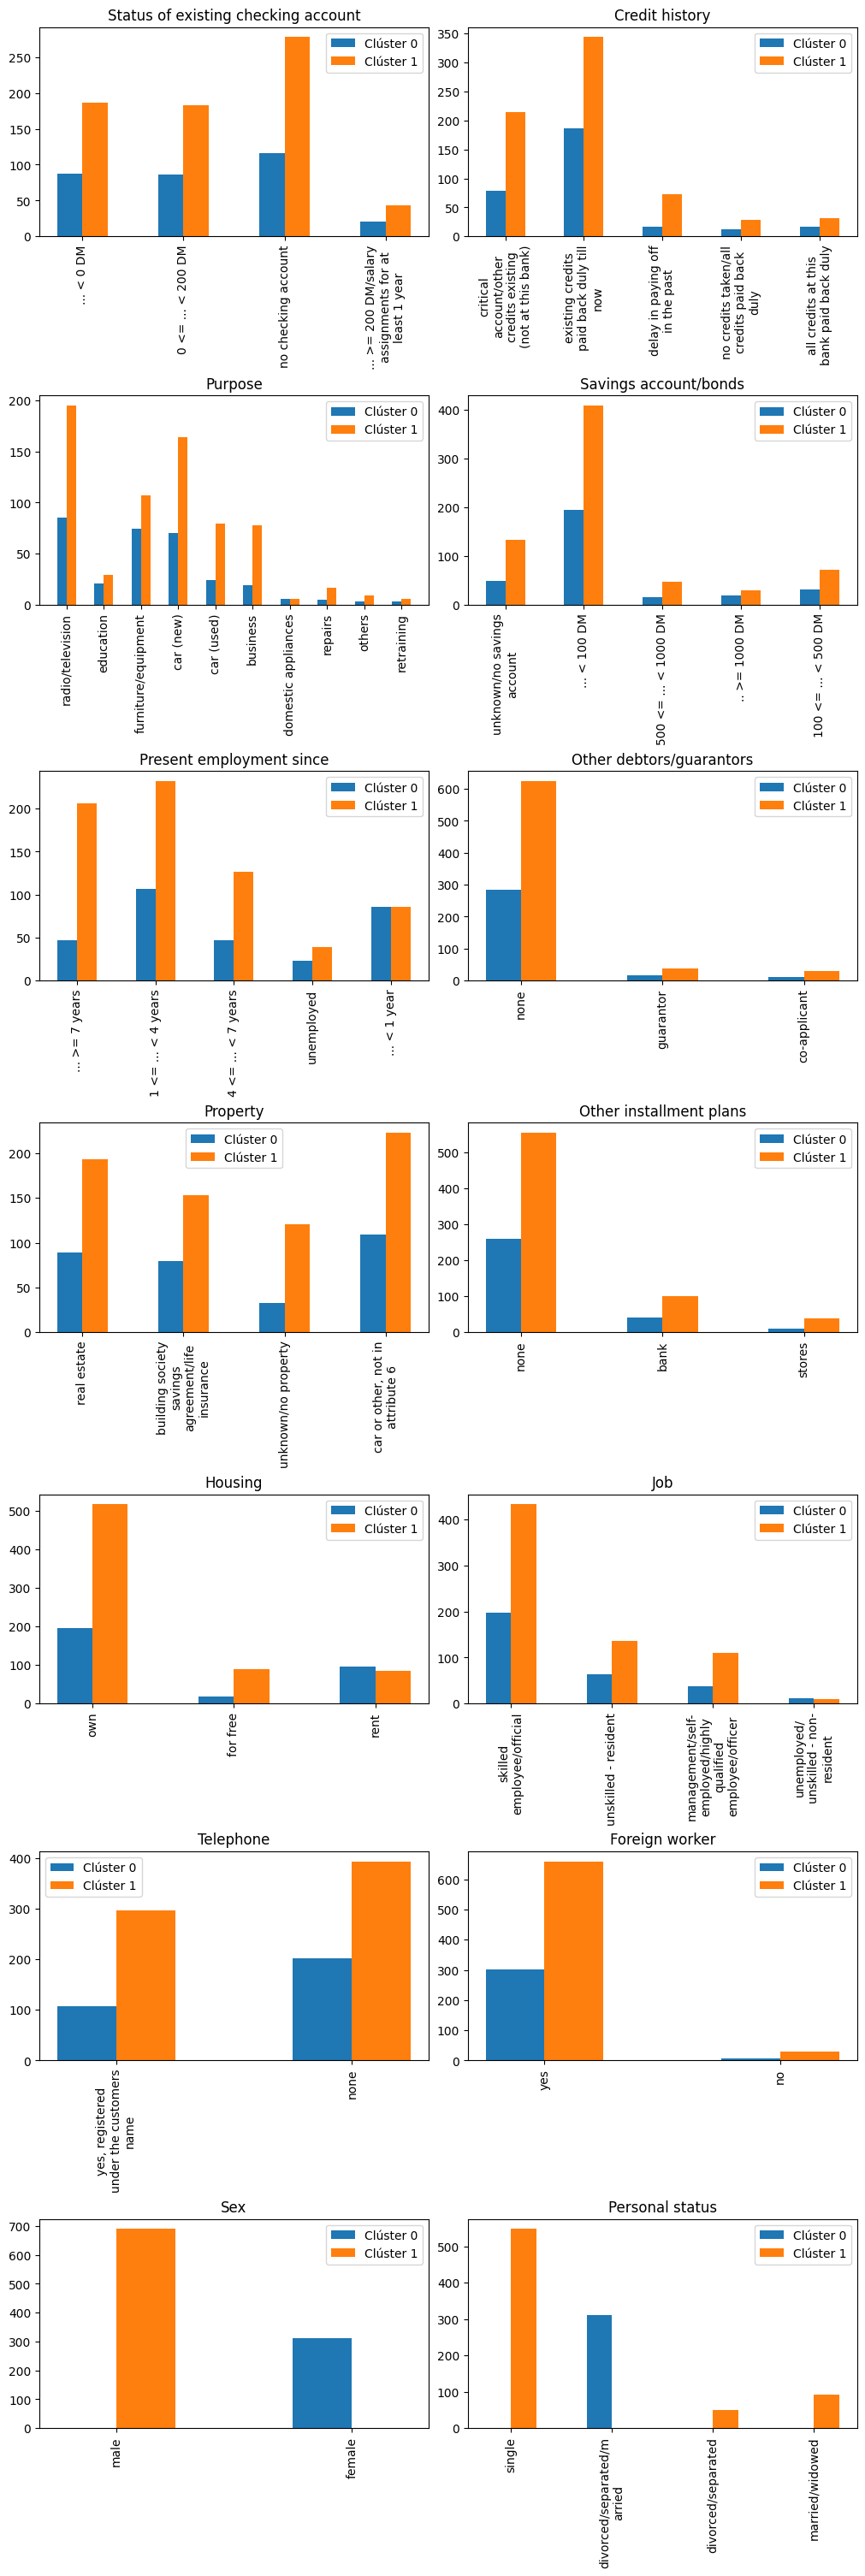

In [9]:
fig, axes = plt.subplots(7, 2,figsize=(10, 30), constrained_layout=True)
axes = axes.flatten()

ancho = 0.25
longitudEtiquetas = 20
for i in range(0,14):
    # Extraemos el nombre de la feature
    nombre_feature = features_categoricas[i]
    
    # Contamos cuantos clientes hay por cluster y por cada categoría dentro de la feature
    resultado = df.groupby(["Cluster", nombre_feature])[nombre_feature].count()\
        .to_frame().rename(columns={nombre_feature:"count"}).reset_index()
    
    # Definimos un dataframe temporal para controlar el orden en el que aparecen las categorías en ambos clústers
    categorias = list(df[nombre_feature].unique())
    num_categorias = len(categorias)
    df_temp = pd.DataFrame({"Cluster":[0]*num_categorias+[1]*num_categorias, nombre_feature:categorias*2})

    #Hacemos un merge entre resultado y df_temp para asegurar que todas las categorías aparezcan, incluso con valor 0 si es necesario
    resultado = df_temp.merge(resultado, on=["Cluster",nombre_feature], how="left").fillna(0)
    
    # Ajustamos el nombre de las categorías para que no sean demasiado largas
    resultado[nombre_feature] = resultado[nombre_feature]\
        .apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))
    
    #Graficamos el resultado
    x = np.arange(num_categorias)
    axes[i].bar(x-ancho*0.5, resultado[resultado["Cluster"]==0]["count"], width=ancho, label='Clúster 0')
    axes[i].bar(x+ancho*0.5, resultado[resultado["Cluster"]==1]["count"], width=ancho, label='Clúster 1')
    axes[i].set_xticks(x, resultado[resultado["Cluster"]==0][nombre_feature], rotation=90)
    axes[i].legend(loc='best')
    axes[i].set_title(nombre_feature)
    
plt.show()

Como podemos ver en las 14 gráficas anteriores (una por cada variable categórica) en general el clúster 1 tiene casi el doble de clientes que el clúster 0, para cada categoría. Sin embargo, hay una gráfica que me pareció muy curiosa, si nos fijamos en la feature "Sex" vemos que solo hay hombres en el clúster 1 y solo hay mujeres en el clúster 0. De esta manera podemos afirmar que nuestro algoritmo K-means para dos clústeres está segmentando entre hombres y mujeres.

# Análisis de componentes principales
Si nosotros quisiéramos visualizar de manera gráfica cada clúster sería imposible ya que, para nuestro caso, necesitaríamos un espacio de 63 dimensiones ya que contamos con 63 variables después del one-hot encoding. Sin embargo, gracias al análisis de componentes principales podemos reducir la dimensionalidad de nuestro espacio a solo 2 o 3 dimensiones, la cuáles si podemos mostrar en un monitor con ayuda de matplotlib. Para visualizar nuestros dos clústers en una gráfica 2D aplicaremos el algoritmo PCA con 2 componentes y graficaremos el resultado:

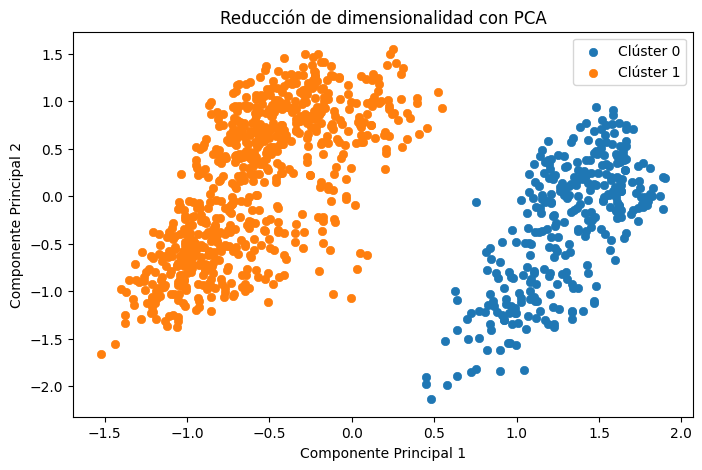

In [10]:
# Definimos el modelo en un pipeline
model = Pipeline(
    steps=[("preprocesamiento", preprocesamiento),
        ("pca", PCA(n_components=2))
    ]
)

# Entrenamiento del modelo y obtención del resultado
X_pca = model.fit_transform(X)

# Graficar cada cluster
plt.figure(figsize=(8, 5))

for cluster in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Clúster {cluster}",
        linewidth=0.5
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Reducción de dimensionalidad con PCA")
plt.legend()

plt.show()

Como podemos notar en análisis de componentes principales exhibe de manera muy marcada dos grupos de puntos. Incluso, si no coloreamos los puntos, aun así podemos distinguir claramente dos grupos. Esto es bastante interesante, ya que de forma natural existe un agrupamiento, y el análisis hecho con K-means junto con el análisis gráfico de la sección anterior, nos reveló que esta segmentación natural corresponde a mujeres (clúster 0 color azul) y hombres (clúster 1 color naranja). 

# Uso de K-means en forma no convencional
El algoritmo K-means es un algoritmo no supervisado que nos permite agrupar puntos de datos simulares en grupos, tal como observamos en la sección anterior. En esta sección vamos a "obligar" al algoritmo a que discrimine entre clientes de bajo riesgo y de alto riesgo. Para hacerlo vamos a usar el algoritmo en una forma no convencional como si se tratara de un algoritmo supervisado y para lograrlo usaremos los siguientes pasos:
1. División de los datos en entrenamiento y prueba
2. Selección de las features (variables independientes) relacionadas con la medición del riesgo "Risk"
3. Usar las features de entrenamiento junto la variable que deseamos predecir "Risk" (variable objetivo dependiente) para entrenar el modelo de K-means
4. Evaluar el modelo en el conjunto de prueba

Como podemos notar, el truco para "obligar" a que nuestro algoritmo no supervisado se comporte como un algoritmo supervisado, está en los pasos 2 y 3. Sin embargo, el paso 2 es realmente truculento ¿cómo sabemos qué variables si están relacionadas con la medición del riesgo? Aquí es donde viene la trampa y la principal razón por la cual esta forma no convencional no se usa en la práctica: usaremos el top 20 variables relacionadas con la medición del riesgo dadas por el algoritmo de regresión logística. Es decir, dependemos de un algoritmo supervisado para convertir a K-means en un algoritmo supervisado, aun así, continuaremos el procedimiento para propósitos de aprendizaje.

Otra dificultad que aparece es en el paso 4, al momento de evaluar nuestro model en los datos de prueba. Dato el conjunto de prueba X tiene 63 dimensiones y nosotros hemos entrenado nuestro modelo con 64 dimensiones (63 independientes más 1 dependiente) entonces la función `predict` va a lanzar un error. Entonces para determinar a que clúster pertenece cada cliente, usaremos una función `predict` totalmente personalizada para nuestro caso.

El código para implementar los pasos anteriores es el siguiente:

In [11]:
# Selección de features
X = df.drop(columns=["Personal status and sex"])

# Identificación de features numéricas
features_numericas = X.select_dtypes(include=["int64"]).columns

# Identificación de features categóricas
features_categoricas = X.select_dtypes(include=["str"]).columns

# Definimos una transformación para el preprocesamiento
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas)
    ]
)

# Selección de las 20 categorias (variables independientes)
# más 2 variables target ("Good" y "Bad" después del one-hot-encoding)
# dadas por el modelo de regresión logística
X_array = preprocesamiento.fit_transform(X)
nombres_features = preprocesamiento.get_feature_names_out()
X = pd.DataFrame(X_array, columns=nombres_features)
X = X[["num__Duration in month",
    "num__Credit amount",
    "num__Installment rate in percentage of disposable income",
    "cat__Status of existing checking account_no checking account",
    "cat__Purpose_education",
    "cat__Credit history_critical account/other credits existing (not at this bank)",
    "cat__Property_unknown/no property",
    "cat__Status of existing checking account_... < 0 DM",
    "cat__Purpose_car (used)",
    "cat__Savings account/bonds_... < 100 DM",
    "cat__Savings account/bonds_.. >= 1000 DM",
    "cat__Foreign worker_no",
    "cat__Housing_for free",
    "cat__Foreign worker_yes",
    "cat__Credit history_no credits taken/all credits paid back duly",
    "cat__Housing_rent",
    "cat__Present employment since_4 <= ... < 7 years",
    "cat__Purpose_car (new)",
    "cat__Personal status_single",
    "cat__Purpose_others",
    "cat__Risk_Bad",
    "cat__Risk_Good"]]

# Selección de la variable objetivo 
y = X["cat__Risk_Bad"]

# Separación de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Eliminamos columnas cat__Risk_Bad y cat__Risk_Good de X_test para hacer predicciones justas
X_test_limpio = X_test.drop(columns=["cat__Risk_Bad","cat__Risk_Good"])

# Definición y entrenamiendo del modelo
model = KMeans(n_clusters=2, random_state=42, n_init="auto")
model.fit(X_train)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 22)","

El código anterior rompe con el pipeline usual que habiamos estado manejando, pero demuestra que si es posible usar K-means como si fuera un algoritmo supervisado. Un punto importante en el código anterior es la linea `X_test_limpio = X_test.drop(columns=["cat__Risk_Bad","cat__Risk_Good"])` ya que esta línea nos asegura que, al evaluar el modelo en los datos de prueba, estos no contengan la variable que deseamos predecir.

Para evaluar nuestro modelo, definamos una función de predicción personalizada que reciba dos parámetros, el modelo de tipo K-means y el dataframe X que contenga los datos de prueba:

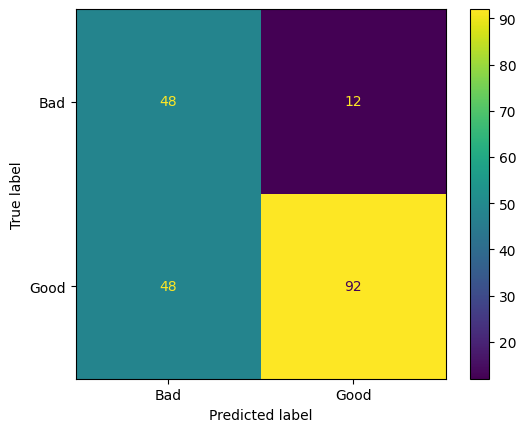

In [12]:
# Definición de una función de predicción personalizada
def prediccion(model, X):
    num_renglones = len(X)
    array = np.zeros(num_renglones, dtype=int)
    centroides_recortados = model.cluster_centers_[:,:-2]
    for i in range(num_renglones):
        vector_0 = X.iloc[i].to_numpy()-centroides_recortados[0]
        vector_1 = X.iloc[i].to_numpy()-centroides_recortados[1]
        distancia_cluster_0 = np.dot(vector_0, vector_0)
        distancia_cluster_1 = np.dot(vector_1, vector_1)
        if distancia_cluster_1 < distancia_cluster_0:
            array[i]=1
    return array

y_pred = prediccion(model, X_test_limpio)
categorias = np.array(["Good", "Bad"])
ConfusionMatrixDisplay.from_predictions(categorias[y_test.to_numpy(dtype=int)], categorias[y_pred])

plt.show()

In [13]:
print("Accuracy :", accuracy_score(y_test.to_numpy(), y_pred))
print("Precision:", precision_score(y_test.to_numpy(), y_pred))
print("Recall   :", recall_score(y_test.to_numpy(), y_pred))
print("F1       :", f1_score(y_test.to_numpy(), y_pred))

Accuracy : 0.7
Precision: 0.5
Recall   : 0.8
F1       : 0.6153846153846154


Al evaluar nuestro modelo obtenemos resultados bastante buenos. El modelo de regresión logística dios los siguientes resultados:

Notemos que el valor de Recall y el F1-Score son superiores en nuestro modelo K-means modificado. Esto era de esperarse ya que los falsos negativos disminuyeron de 28 (regresión logística) a 12 (K-means modificado). Recordemos que Recall es sensible a los cambios en los falsos negativos y por eso era de esperarse que el Recall aumentara. Además el F1-Score, al ser la media armónica entre Precision y Recall, era de esperase que también aumentara de valor.

Lo anterior significa que ¿el modelo de K-means modificado es mejor un modelo de regresión logística? Lamentablemente no. Ya vimos que para llegar modificar el comportamiento de K-means se necesitan conocer de antemano las variables independientes que mejor predicen la variable dependiente. Pero además hay otro detalle, el algoritmo de regresión logística por si solo puede ajustarse para dar valores de Recall y F1-Score tan buenos como los del K-means modificado. Basta ajustar el valor de threshold de la regresión logística para disminuir los falsos negativos, esto que ocasionará que se incrementen los falsos positivos y obtengamos así resultados similares a nuestro algoritmo de K-means modificado.

Por lo tanto, el desarrollo anterior solo es con fines experimentales, es decir, de aprendizaje y no se recomienda implementar en un ambiente productivo dicho algoritmo modificado.

# Análisis de componentes principales (segunda revisión)
Para finalizar esta demo, vamos a ver cómo se modificó nuestro espacio dimensional. De las 63 features y 2 targets, pasamos a entrenar al algoritmo modificado con 20 features predictoras del riesgo más 2 targets (el target "cat__Risk_Bad" y "cat__Risk_Good", ambas son básicamente la misma variable, por lo tanto son redundantes).

Lo que haremos en esta sección es tomar las 22 variables y reducirlas a un espacio 2-dimensional, nuevamente con ayuda del algorirmo PCA. En teoría este subconjunto de variables debe de conducir a dos clústers, pero esta vez, cada clúster debería ser representativo de las clases "Good" y "Bad".

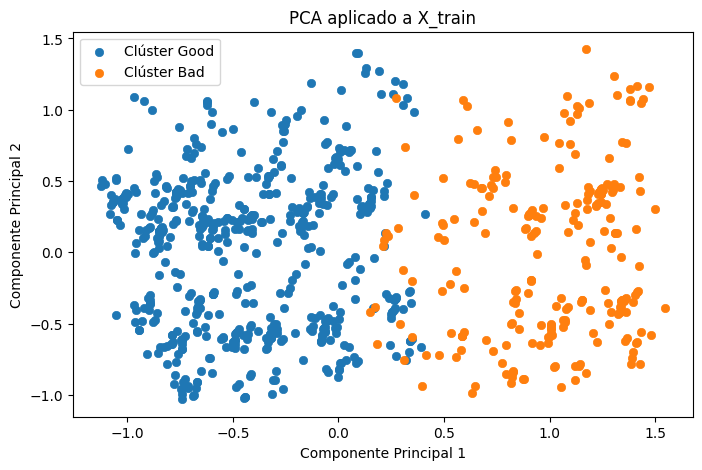

In [46]:
# Definimos el modelo
model_pca = PCA(n_components=2)

# Entrenamiento del modelo y obtención del resultado
X_pca = model_pca.fit_transform(X_train)

# Graficar cada cluster
plt.figure(figsize=(8, 5))
categorias = ["Good","Bad"]

for cluster in [0, 1]: #Recordemos que para la columna cat__Risk_Bad 1 representa la categoria positiva "Bad"
    mask = X_train["cat__Risk_Bad"] == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Clúster {categorias[cluster]}",
        linewidth=0.5
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA aplicado a X_train")
plt.legend()

plt.show()

Como podemos observar, cuando nos restringimos a las variables predictoras del riesgo y al reducir la dimensionalidad a 2D entonces ya no es tan fácil distinguir dos clústeres aislado uno del otro. En este caso, podemos ver que en el Clúster 0 corresponde a la categoría "Good" y el clúster 1 a la categoría "Bad". Además, en el caso de la gráfica anterior, los colores no están dados por las predicciones del modelo si no que están dados por los valores reales (ya que estamos usando X_train).

Antes de continuar, es educativo revisar ¿qué pasa si en X_train quito las variables que quiero predecir "cat__Risk_Bad" y "cat__Risk_Good" y aplico una reducción de dimensionalidad? La respuesta se muestra a continuación:

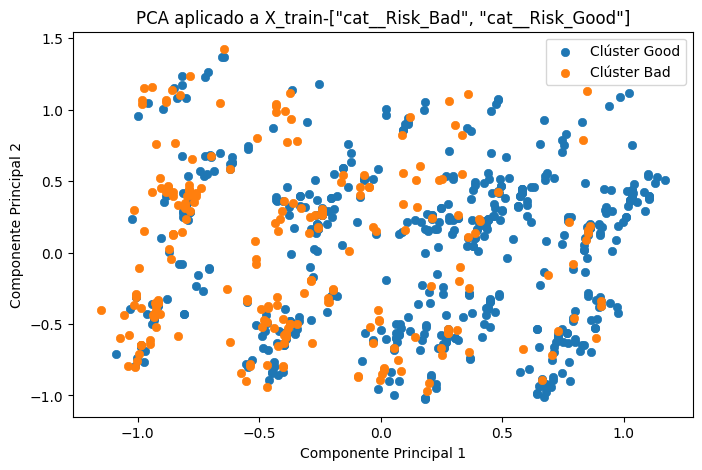

In [17]:
# Entrenamiento del modelo y obtención del resultado
X_pca = model_pca.fit_transform(X_train.drop(columns=["cat__Risk_Bad", "cat__Risk_Good"]))

# Graficar cada cluster
plt.figure(figsize=(8, 5))
categorias = ["Good","Bad"]

for cluster in [0, 1]: #Recordemos que para la columna cat__Risk_Bad 1 representa la categoria positiva "Bad"
    mask = X_train["cat__Risk_Bad"] == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Clúster {categorias[cluster]}",
        linewidth=0.5
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title('PCA aplicado a X_train-["cat__Risk_Bad", "cat__Risk_Good"]')
plt.legend()

plt.show()

Como podemos notar, cuando en X_train quitamos las variables que queremos predecir entonces los clústeres se revuelven entre si, si no fuera por los colores entonces prácticamente no seriamos capaces de distinguirlos. El efecto de incorporar las variables "cat__Risk_Bad", "cat__Risk_Good" en X_train es realmente apreciable y esto facilita que el algoritmo de K-means identifique los clústeres.

Si queremos ver como nuestro modelo predice entre "Good" y "Bad" apliquemos PCA al conjunto `X_test` (que si contiene las variables predictoras) y las predicciones almacenadas en `y_pred`:

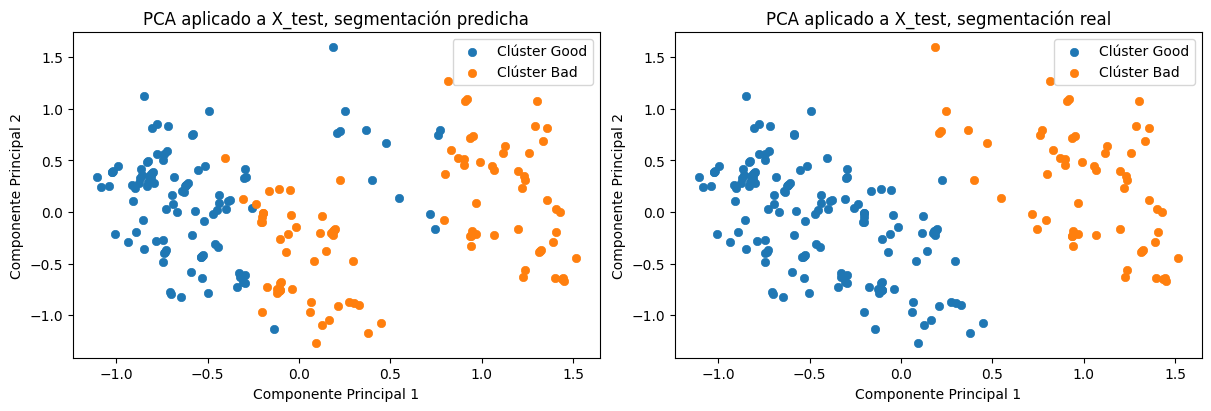

In [45]:
# Entrenamiento del modelo y obtención del resultado
X_pca = model_pca.fit_transform(X_test)

# Graficar cada cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes = axes.flatten()
categorias = ["Good","Bad"]

for cluster in [0,1]:
    mask = y_pred == cluster
    
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Clúster {categorias[cluster]}",
        linewidth=0.5
    )

axes[0].set_xlabel("Componente Principal 1")
axes[0].set_ylabel("Componente Principal 2")
axes[0].set_title("PCA aplicado a X_test, segmentación predicha")
axes[0].legend()

for cluster in [0,1]:
    mask = X_test["cat__Risk_Bad"] == cluster
    
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Clúster {categorias[cluster]}",
        linewidth=0.5
    )

axes[1].set_xlabel("Componente Principal 1")
axes[1].set_ylabel("Componente Principal 2")
axes[1].set_title("PCA aplicado a X_test, segmentación real")
axes[1].legend()

plt.show()

La gráfica anterior deja ver de una manera diferente como K-means comete errores en el conjunto de prueba `X_test`. Si el algoritmo fuera perfecto, entonces la gráfica debería de verse como la derecha, sin embargo, las predicciones que hace K-means se muestran a la izquierda. Claramente en la gráfica de la izquierda se ve como el modelo comete errores.

Quizás algún lector estará pensando, al ver la gráfica de la derecha, que el algoritmo PCA discrimina perfectamente entre los grupos Good y Bad y tiene razón. El algoritmo PCA muestra dos clústeres perfectamente distinguibles entre sí para el conjunto `X_train`, sin embargo, recordemos que `X_train` contiene las variables que deseamos predecir. Es por esta razón que insistimos en crear el conjunto `X_train_limpio` que no contiene las variables predictoras para hacer una evaluación justa del modelo K-means.